# Notebook to explore how detsim works internally to change it to only the smearing part for the NN studies

# Creating SENSIM

In [ ]:
import os

os.environ['ICTDIR'] = '/Users/mperez/NEXT/IC/'

import numpy as np
import pandas as pd
import tables as tb
from invisible_cities.dataflow import dataflow      as fl

import matplotlib.pyplot as plt

from invisible_cities.core.system_of_units import eV, mm, cm, ms, mus, ns, hertz

from invisible_cities.cities.components import check_max_time, MC_hits_and_part_from_files, create_timestamp, print_every
from invisible_cities.database          import load_db       as db

from invisible_cities.detsim.light_tables_c     import LT_SiPM
from invisible_cities.detsim.light_tables_c     import LT_PMT
from invisible_cities.detsim.simulate_electrons import generate_ionization_electrons, drift_electrons, diffuse_electrons, distribute_hits_energy_among_electrons

from invisible_cities.cities.diffsim import filter_hits_after_max_time, hits_selector
from invisible_cities.cities.diffsim import ielectron_simulator_diffsim

from invisible_cities.io.mcinfo_io import load_mchits_df
from invisible_cities.core.configure import event_range

In [2]:
import sys
from invisible_cities.io.dst_io import load_dst
sys.path.append(os.getenv('HOME') + '/NEXT/data_labelling/')

from utils.plotting_utils import plot_3d_hits, plot_3d_vox, plot_cloud_voxels_and_hits, plot_cloud_voxels_and_hits_discrete

In [3]:
files_in    =  ["/Users/mperez/detsim_vox/nexus/nexus_31_0nubb.h5"] # ["/Users/mperez/detsim_vox/nexus/nexus_1_0nubb_5bar.h5"] #, "/Users/mperez/detsim_vox/nexus/nexus_1_20evs_1eroi.h5"
file_out    = "/Users/mperez/detsim_vox/sensim/prueba.h5"
compression = "ZLIB4"
run_number  = 0
detector_db = "next100_5mm" # "next100_15mm"
print_mod   = 1
event_range = (None, )

s1_lighttable = "/Users/mperez/detsim_vox/LightTables/NEXT100_S1_LT.h5"
s2_lighttable = "/Users/mperez/detsim_vox/LightTables/NEXT100_S2_LT.h5"
sipm_psf      = "/Users/mperez/detsim_vox/LightTables/NEXT100_PSF.h5"

physics_params = dict(wi = 22.0 * eV,
                      fano_factor = 0.15,
                      conde_policarpo_factor = 0.4,
                      drift_velocity         = 1.05  * mm / mus,
                      el_drift_velocity      = 4.55  * mm / mus,
                      transverse_diffusion   = 1.44  * mm / cm**0.5,
                      longitudinal_diffusion = 0.408 * mm / cm**0.5,
                      el_gain                = 855,
                      lifetime               = 10 * ms,
                      mesh_displacement      = 0 * mm)

buffer_params = dict(pmt_width   =  25  * ns,
                     sipm_width  =   1  * mus,
                     max_time    = 3000 * mus,
                     length      = 1500 * mus,
                     pre_trigger =  10  * mus,
                     trigger_thr =   0)

zvox_params = {'zmin' : 0, 'zmax' : 1500, 'zrebin' : 10}

label_params = {'sig_creator'     : 'none', 
                'segclass_dct'    : {'other':1, 'track':2, 'blob':3}, 
                'delta_ener_loss' : 0.25}

rate = 0.5 * hertz
qcut = 3

In [4]:
buffer_params_  = buffer_params .copy()
physics_params_ = physics_params.copy()

buffer_params_["max_time"] = check_max_time(buffer_params_["max_time"], buffer_params_["length"])

# ws    = physics_params_.pop("ws")
el_dv = physics_params_.pop("el_drift_velocity")

# derived parameters
datapmt  = db.DataPMT (detector_db, run_number)
datasipm = db.DataSiPM(detector_db, run_number)
lt_pmt   = LT_PMT (fname=os.path.expandvars(s2_lighttable))
lt_sipm  = LT_SiPM(fname=os.path.expandvars(sipm_psf), sipm_database=datasipm)
el_gap   = lt_sipm.el_gap_width

In [34]:
db_n100 = db.DataSiPM('next100', run_number)
db_n100_15mm = db.DataSiPM('next100_15mm', run_number)
db_n100_10mm = db.DataSiPM('next100_10mm', run_number)
db_n100_5mm  = db.DataSiPM('next100_5mm',  run_number)

<BarContainer object of 4 artists>

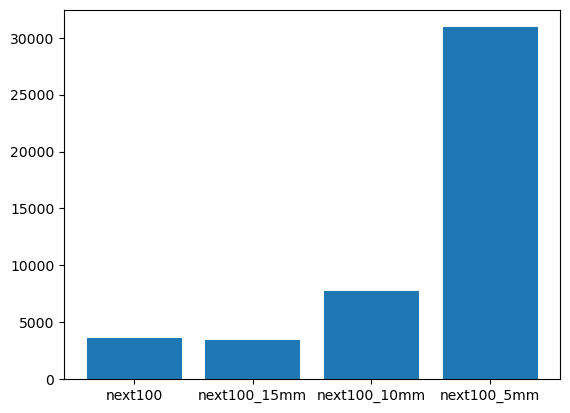

In [48]:
plt.bar(['next100', 'next100_15mm', 'next100_10mm', 'next100_5mm'], [len(db_n100), len(db_n100_15mm), len(db_n100_10mm), len(db_n100_5mm)])

In [54]:
(15/10) **2, len(db_n100_10mm) / len(db_n100_15mm) 

(2.25, 2.252257500728226)

In [55]:
(10/5) ** 2, len(db_n100_5mm) / len(db_n100_10mm) 

(4.0, 3.9985773409208485)

In [56]:
(15/5) ** 2, len(db_n100_5mm) / len(db_n100_15mm) 

(9.0, 9.005825808330906)

Select an event for example

In [6]:
for i, event in enumerate(MC_hits_and_part_from_files(files_in, rate)):
    if i == 48: #111:
        break

Filter delayed hits

In [7]:
#filters hits a times larger than max_time config parameter (ok?)
#filter_delayed_hits
event['x'], event['y'], event['z'], event['energy'], event['time'], event['label'], event['hit_id'], event['hit_part_id'] = filter_hits_after_max_time(buffer_params_["max_time"])(event['x'], 
                                                                                                                                            event['y'], 
                                                                                                                                            event['z'], 
                                                                                                                                            event['energy'], 
                                                                                                                                            event['time'], 
                                                                                                                                            event['label'], 
                                                                                                                                            event['hit_id'],
                                                                                                                                            event['hit_part_id'],
                                                                                                                                            event['event_number'])

Select S1 candidate hits

In [8]:
#selecciona los hits que están en ACTIVE y BUFFER
#select_s1_candidate_hits
event['x'], event['y'], event['z'], event['energy'], event['time'], event['label'], event['hit_id'], event['hit_part_id'] = hits_selector(False)(event['x'], 
                                                                                                            event['y'], 
                                                                                                            event['z'], 
                                                                                                            event['energy'], 
                                                                                                            event['time'], 
                                                                                                            event['label'], 
                                                                                                            event['hit_id'],
                                                                                                            event['hit_part_id'],
                                                                                                            event['name'], 
                                                                                                            event['name_id'])

Select ACTIVE hits

In [9]:
#selecciona los hits que están en ACTIVE
#select_active_hits
event['x_a'], event['y_a'], event['z_a'], event['energy_a'], event['time_a'], event['labels_a'], event['hit_id_a'], event['hit_part_id_a'] = hits_selector(True)(event['x'], 
                                                                                                                        event['y'], 
                                                                                                                        event['z'], 
                                                                                                                        event['energy'], 
                                                                                                                        event['time'], 
                                                                                                                        event['label'], 
                                                                                                                        event['hit_id'],
                                                                                                                        event['hit_part_id'],
                                                                                                                        event['name'], 
                                                                                                                        event['name_id'])

Filter events with no active hits (Then in the city they write them and also just pass the ones that passed the filter)

In [10]:
# checks if there is at least one active hit in the event
# filter_events_no_active_hits
event['passed_active'] = (lambda x:np.any(x))(event['energy_a'])

# writes for this event the variable "passed_active", that is, if there is at least one active hit in the event; not necessary to use here
# write_nohits_filter

# I understand that it filters the events that had "passed_active" as True, or counts them; not necesary  to use here
# events_passed_active_hits

### Here we create the bins

This is done already here to have the borders for the fiducial

In [11]:
def bins_creator_sensim(datasipm, zmin, zmax, z_rebin, dv, sipm_width):
    xsipm, ysipm = datasipm["X"], datasipm["Y"]

    xmin, xmax = xsipm.min(), xsipm.max()
    ymin, ymax = ysipm.min(), ysipm.max()

    xbin = round(xsipm.drop_duplicates().sort_values().diff().dropna().max(), 3)
    ybin = round(ysipm.drop_duplicates().sort_values().diff().dropna().max(), 3)
    zbin = dv * sipm_width * z_rebin

    bin_info = dict(min = (xmin - xbin / 2, ymin - ybin / 2, zmin), 
                    max = (xmax + xbin / 2, ymax + ybin / 2, zmax), 
                    binsize = (xbin, ybin, zbin))

    def create_bins():
        bins = []
        for mi, ma, si in zip(bin_info['min'], bin_info['max'], bin_info['binsize']):
            bins.append(np.arange(mi, ma + si, si))
        return tuple(bins), bin_info
    return create_bins

In [12]:
bins, bin_info = bins_creator_sensim(datasipm, zvox_params['zmin'], zvox_params['zmax'], zvox_params['zrebin'], physics_params['drift_velocity'], buffer_params['sipm_width'])()

Add a fiducial cut just in case the MC hits are outside the boundaries of the SiPM plane.

It wouldn't be a problem, we would just take into account the SiPMs that receive light, but the MC would have some hits outside the voxelization I'm creating. I could try adding more voxels to the grid: in that way, the sensim tracks would occupy the same, but the MC tracks that are beyond the SiPMs grid, would appear... In fact this wouldn't be the best solution at all but...

In [13]:
from invisible_cities.cities.diffsim import event_fiducial_selector

In [14]:
event['passed_fiducial_mc'] = event_fiducial_selector(**{key:(bin_info['min'][i], bin_info['max'][i]) for i, key in enumerate(['xlim', 'ylim', 'zlim'])})(event['x_a'], event['y_a'], event['z_a'])

In [15]:
event['passed_fiducial_mc']

True

New we label them (first extract the binary class, then create the MC hits + particles DataFrame and finally assign the segmentation class to all hits)

In [16]:
from invisible_cities.cities.diffsim import binclass_creator, segclass_creator, hits_particle_df_creator

In [17]:
event['binclass'] = binclass_creator(label_params['sig_creator'])(event['particle_id'], event['particle_name'], event['creator_proc'], event['hit_part_id'])

event['hits_part_df'] = hits_particle_df_creator()(event['hit_part_id_a'], 
                                                    event['hit_id_a'], 
                                                    event['energy_a'], 
                                                    event['particle_id'], 
                                                    event['particle_name'], 
                                                    event['creator_proc'])

event['segclass_a'], event['ext_a'] = segclass_creator(**label_params)(event['hits_part_df'], event['binclass'])

### We need to voxelize MC to do the decolabel. The voxelization in sensim follows the SiPMs pitch, so we need to create the bins for this

### Cuando voxelize MC, en Z que voxelizo? El tiempo directamente no, pero sería el drift time?? dt = t + z/dv + mesh_disp /dv_EL (?) --> este drift time lo paso a z again using dv --> z_final = dt * dv (que ahora pues tiene en cuenta un poquito las diferncias de tiempos en los que se producen los hits I guess) --> es decir, con hacer z_final = t * dv + z + mesh_disp * (dv / dv_EL) YA ESTÁ

### Before voxelizing then, we correct the z postion as said above

In [18]:
def mc_z_drifted(dv, dv_el, mesh_disp):
    '''
    Function that adds the drift time to the z MC position
    '''
    def drift_mc_z(z, time):
        correct_z = z + time * dv + mesh_disp * dv / dv_el
        return correct_z
    return drift_mc_z

In [19]:
event['z_a_corr'] = mc_z_drifted(physics_params['drift_velocity'], physics_params['el_drift_velocity'], physics_params['mesh_displacement'])(event['z_a'], event['time_a'])

### Here we create the bins

In [20]:
def bins_creator_sensim(datasipm, zmin, zmax, z_rebin, dv, sipm_width):
    xsipm, ysipm = datasipm["X"], datasipm["Y"]

    xmin, xmax = xsipm.min(), xsipm.max()
    ymin, ymax = ysipm.min(), ysipm.max()

    xbin = round(xsipm.drop_duplicates().sort_values().diff().dropna().max(), 3)
    ybin = round(ysipm.drop_duplicates().sort_values().diff().dropna().max(), 3)
    zbin = dv * sipm_width * z_rebin

    bin_info = dict(min = (xmin - xbin / 2, ymin - ybin / 2, zmin), 
                    max = (xmax + xbin / 2, ymax + ybin / 2, zmax), 
                    binsize = (xbin, ybin, zbin))

    def create_bins():
        bins = []
        for mi, ma, si in zip(bin_info['min'], bin_info['max'], bin_info['binsize']):
            bins.append(np.arange(mi, ma + si, si))
        return tuple(bins), bin_info
    return create_bins

In [21]:
bins, bin_info = bins_creator_sensim(datasipm, zvox_params['zmin'], zvox_params['zmax'], zvox_params['zrebin'], physics_params['drift_velocity'], buffer_params['sipm_width'])()

### And we voxelize using the corrected z and the diffsim function

In [22]:
from invisible_cities.cities.diffsim import voxel_creator

In [23]:
event['xbin_mc'], event['ybin_mc'], event['zbin_mc'], event['_'], event['_'], event['_'], event['ebin_mc'], event['_'], event['segbin_mc'] = voxel_creator(bins)(event['x_a'], 
                                                                                                                                                             event['y_a'], 
                                                                                                                                                             event['z_a_corr'],  
                                                                                                                                                             event['energy_a'], 
                                                                                                                                                             event['time_a'], 
                                                                                                                                                             event['segclass_a'])

### We'll use them later

After this first filtering proccess MC labelling, diffsim really starts to do its thing. The next fucntion does almost it all:

* Simulates electron creation (generate_ionization_electrons)
* Drift (drift_electrons)
* Diffusion (diffuse_electrons)
* Photon generation in the EL (some final lines in the code)

I think that we wanted first to add diffusion only, without the EL effects. This function gives x, y, z with diffusion, and times + number of photons (which is for the second part). So, I think that having it up until here is enough! 

I have added two simple things to the ielectron simulator to have what we need: 

* A function to distribute the energy of the hits among their ionization electrons
* The propagation of the segmentation label from a hit to all its ionization electrons

In [24]:
from invisible_cities.cities.sensim import ielectron_simulator_sensim

In [25]:
# this function does all the steps: simulates electron creation, drift, diffusion and photon generation in the EL
# the result gives all the ionization electrons, times (I think of arrival to the EL?) and the N of photons that generates each one
# simulate_electrons
event['x_ph'], event['y_ph'], event['z_ph'], event['energy_ph'], event['times_ph'], event['nphotons'], event['segclass_ph'] = ielectron_simulator_sensim(**physics_params_)(event['x_a'], 
                                                                                                                                                                            event['y_a'], 
                                                                                                                                                                            event['z_a'], 
                                                                                                                                                                            event['time_a'], 
                                                                                                                                                                            event['energy_a'], 
                                                                                                                                                                            event['segclass_a'])

Filter events with no light (write them and also eliminate the ones that don't pass)

In [26]:
# checks if the event has any photon
# count_photons
event['enough_photons'] = (lambda x:np.sum(x) > 0)(event['nphotons'])

# writes for this event the variable "enough_photons", that is, if there is at least one photon; not necessary to use for us
# write_dark_evt_filter

# I understand that it filters the events that had "enough_photons" as True, or counts them; not necesary  to use for us
# dark_events

Get buffer times and length

In [27]:
from invisible_cities.cities.sensim import buffer_times_and_length_getter

In [28]:
event['tmin'], event['buffer_length'] = buffer_times_and_length_getter(buffer_params_["pmt_width"],
                                                     buffer_params_["sipm_width"],
                                                     el_gap, el_dv,
                                                     buffer_params_["max_time"])(event['time'], event['times_ph'])

It gets the start time of the event (from the minimum `time` value, which is the start of the event), and the end time (from the max of `times_ph`, which already includes the time of drift, and also we add here the time of the drift through the EL).

Those times are transformed into min/max bins (divided by the `max_sensor_bin`, appliying floor/ceil, and multiplying it back again for `max_sensor_bin`) so we have the initial time and the length of the whole WF.

Create the S2 waveform

In [29]:
from invisible_cities.cities.sensim import s2_waveform_creator_sensim

In [30]:
event['sipm_bin_wfs'] = s2_waveform_creator_sensim(buffer_params_["sipm_width"], lt_sipm, el_dv)(event['x_ph'], event['y_ph'], event['times_ph'], event['segclass_ph'], event['nphotons'], event['tmin'], event['buffer_length'])


Taking a look into the function, it doesn't seem like it needs any additional parameter. Just need to create a new PSF file from the original one where the first N columns (N = 10 mm - D mm for  a D mm EL, where 10 mm is the original gap of the PSF we are "adapting"), which are the ones further away from the TP, are deleted. Also need the EL_GAP parameter in its config is changed.

#### Reduce EL size in the PSF

I think I'll need to create another .h5 where I'm saving the same PSF with different configurations, which would be mainly changing the EL_GAP parameter from the `Config` and `configuration`; also the main table, reducing the number of columns I guess

With the next function, I pick the PSF, change the values of EL_GAP, and select the desired columns. Take into account that $z_1$ is the one bin that originally is closest to the mesh when the PSF was created (for a 10mm gap); that is, the binning is from [0, -1], so $z_{10}$ would be the last bin, from [-9, -10]. So for reducing the EL, we would have to pick the "last" slices, the ones that are the closest to the TP.

In [30]:
from invisible_cities.io.dst_io import load_dst, df_writer

def create_reduced_psf(psf_file, new_psf_file, new_psf_size = 5):
    file = os.path.expandvars(psf_file)
    psf_df = load_dst(file, "PSF", "LightTable")
    config = load_dst(file, "PSF", "Config")
    configuration = load_dst(file, "PSF", "configuration")

    new_psf_columns = ['z_m{}'.format(i) for i in range(new_psf_size + 1, len(psf_df.columns))]
    psf_df_red = psf_df[['dist_xy'] + new_psf_columns]
    config.loc[config['parameter'] == 'EL_GAP', 'value'] = str(float(new_psf_size))
    configuration.loc[configuration['parameter'] == 'EL_GAP', 'value'] = str(float(new_psf_size))

    with tb.open_file(new_psf_file, 'w') as h5in:
        df_writer(h5in, psf_df_red, "PSF", "LightTable")
        df_writer(h5in, config, "PSF", "Config", str_col_length = config.applymap(lambda x: len(x)).values.max())
        df_writer(h5in, configuration, "PSF", "configuration", str_col_length = configuration.applymap(lambda x: len(x)).values.max())

# create_reduced_psf(sipm_psf, '/Users/mperez/detsim_vox/LightTables/NEXT100_PSF_5mm_EL.h5', new_psf_size = 5)

#### And thats how the PSF is adapted for a 5mm EL

Get the SiPM bins:

In [31]:
from invisible_cities.cities.sensim import bin_edges_getter_sensim

In [32]:
event['sipm_bins'] = bin_edges_getter_sensim(buffer_params_["sipm_width"])(event['sipm_bin_wfs'])

Get the df from the WF:

In [33]:
from invisible_cities.cities.sensim import sns_signal_getter

In [34]:
def sns_signal_getter(datasipm, dv, qcut):
    '''
    Using the SiPM WF bins, this function creates a dataframe with the pes 
    for each SiPM in each time bin (Z position)
    Also uses qcut to put a threshold on the pes of each SiPM
    '''
    def get_sns_signal(sipm_bin_wfs_seg, sipm_bins, event_energy):
        # collapse all the 3 histograms into one 
        sipm_bin_wfs = sipm_bin_wfs_seg.sum(axis = 0)
        # extract the sipms that had signal in a certain time bin
        values_index = sipm_bin_wfs.nonzero()

        # get the positions of those sipms
        xy_positions = datasipm.loc[values_index[0]][['X', 'Y']].rename(columns = {'X':'x_sipm', 'Y':'y_sipm'})
        x_sipm, y_sipm = xy_positions.x_sipm.values, xy_positions.y_sipm.values
        # get the time bin of those and transform into Z position
        tbin = sipm_bins[values_index[1]]
        z_slice = tbin * dv

        # get the number of photons
        pes = sipm_bin_wfs[values_index]

        # get the segmentation class from 3 histograms, choosing the label that created more gammas in a sensor and bin
        seg_bin_wfs = sipm_bin_wfs_seg.argmax(axis = 0)
        # choose only where there is any signal
        seg = seg_bin_wfs[values_index] + 1 # returning to original labels

        # Do the cut in Q
        q_mask = pes > qcut
        #  THIS SHOULD BE DONE AFTER IN THE DF CREATION THEN
        # # Create the df
        # sipm_df = xy_positions.copy()
        # sipm_df['z_slice']  = zbin
        # sipm_df['pes']      = pes
        # sipm_df['segclass'] = seg + 1 # return to original labels, because here we used position 
        # sipm_df['event']    = nevent
        # sipm_df['binclass'] = binclass

        # # We put a threshold on pes for the SiPMs
        # sipm_df = sipm_df[sipm_df['pes'] > qcut]

        # # Finally we distribute the total energy of the event
        # sipm_df['energy']   = (sipm_df['pes'] / sipm_df['pes'].sum()) * event_energy.sum()
        energy = (pes[q_mask] / pes[q_mask].sum()) * event_energy.sum()

        return x_sipm[q_mask], y_sipm[q_mask], z_slice[q_mask], energy, pes[q_mask], seg[q_mask] # sipm_df[['event', 'x_sipm', 'y_sipm', 'z_slice', 'energy', 'pes', 'binclass', 'segclass']]
    return get_sns_signal

### So I take the WFs and create the positions and pes for each minimum slice with a cut in q as I did before, but without creating a df because I'd like to voxelize it

In [35]:
event['x_sns'], event['y_sns'], event['z_sns'], event['ener_sns'], event['pes_sns'], event['seg_sns'] = sns_signal_getter(datasipm, physics_params_["drift_velocity"], qcut)(event['sipm_bin_wfs'], event['sipm_bins'], event['energy_ph'])

### And create a df with it

In [36]:
def sns_df_creator():
    def create_sns_df(evt, x, y, z, energy, pes, binclass, segclass):
        return pd.DataFrame({'event'    : evt, 
                             'x_sipm'   : x, 
                             'y_sipm'   : y, 
                             'z_slice'  : z, 
                             'energy'   : energy, 
                             'pes'      : pes, 
                             'binclass' : binclass,
                             'segclass' : segclass})
    return create_sns_df

In [37]:
event['sns_df'] = sns_df_creator()(event['event_number'], event['x_sns'], event['y_sns'], event['z_sns'], event['ener_sns'], event['pes_sns'], event['binclass'], event['seg_sns'])

### Now I voxelize it

In [38]:
event['x_bin'], event['y_bin'], event['z_bin'], event['x_mean'], event['y_mean'], event['z_mean'], event['e_bin'], event['pes_bin'], event['seg_bin'] = voxel_creator(bins)(event['x_sns'], event['y_sns'], event['z_sns'], event['ener_sns'], event['pes_sns'], event['seg_sns'])

### Assign to those voxels the extreme label as in diffsim

In [39]:
from invisible_cities.cities.diffsim import extlabel_creator

In [40]:
event['new_seg_bin'], event['ext_bin'] = extlabel_creator(label_params['segclass_dct'], bins)(event['x_a'], 
                                                                                        event['y_a'], 
                                                                                        event['z_a_corr'], 
                                                                                        event['ext_a'], 
                                                                                        event['x_bin'], 
                                                                                        event['y_bin'], 
                                                                                        event['z_bin'], 
                                                                                        event['seg_bin'], 
                                                                                        event['binclass'])

In [41]:
len(event['ext_bin'])

3452

### Assign now the decolabel superposing both mc and non mc bins

In [42]:
from invisible_cities.cities.diffsim import decolabel_creator

In [43]:
event['deco_bin'] = decolabel_creator()(event['x_bin'], event['y_bin'], event['z_bin'], event['xbin_mc'], event['ybin_mc'], event['zbin_mc'])

In [44]:
diff = pd.DataFrame({'x':event['x_bin'], 'y':event['y_bin'], 'z':event['z_bin']})
norm = pd.DataFrame({'x':event['xbin_mc'], 'y':event['ybin_mc'], 'z':event['zbin_mc']})

In [45]:
len(diff)

3452

In [46]:
len(norm)

156

In [47]:
(diff.merge(norm, how = 'outer', indicator = True))

,x,y,z,_merge
0,38,57,2,left_only
1,42,78,2,left_only
2,44,82,2,left_only
3,45,47,2,left_only
4,48,49,6,left_only
...,...,...,...,...
3448,125,8,2,left_only
3449,127,98,6,left_only
3450,129,27,2,left_only
3451,174,72,2,left_only


#### Creamos el df

In [48]:
def sns_vox_df_creator():
    def create_sns_vox_df(evt, x, y, z, xmean, ymean, zmean, energy, pes, binclass, segclass, decolabel, extlabel):
        return pd.DataFrame({'event'     : evt, 
                             'xbin'      : x, 
                             'ybin'      : y, 
                             'zbin'      : z, 
                             'x_mean'    : xmean,
                             'y_mean'    : ymean,
                             'z_mean'    : zmean,
                             'ebin'      : energy, 
                             'pesbin'    : pes, 
                             'binclass'  : binclass,
                             'segclass'  : segclass, 
                             'decolabel' : decolabel,
                             'extlabel'  : extlabel})
    return create_sns_vox_df

In [49]:
event['sns_vox_df'] = sns_vox_df_creator()(event['event_number'], event['x_bin'], event['y_bin'], event['z_bin'],  event['x_mean'], event['y_mean'], event['z_mean'], event['e_bin'], event['pes_bin'], event['binclass'], event['new_seg_bin'], event['deco_bin'], event['ext_bin'])

Filter events with no light (write them and also eliminate the ones that don't pass)

In [51]:
# checks if the event has any photon
# count_photons
event['enough_photons'] = (lambda x:np.sum(x) > 0)(event['nphotons'])

# writes for this event the variable "enough_photons", that is, if there is at least one photon; not necessary to use for us
# write_dark_evt_filter

# I understand that it filters the events that had "enough_photons" as True, or counts them; not necesary  to use for us
# dark_events

In [52]:
event['sns_vox_df']

,event,xbin,ybin,zbin,x_mean,y_mean,z_mean,ebin,pesbin,binclass,segclass,decolabel,extlabel
0,24948,38,57,2,-305.0,-210.0,29.40,0.000043,4,1,2,0,0
1,24948,42,78,2,-285.0,-105.0,30.45,0.000043,4,1,1,0,0
2,24948,44,82,2,-275.0,-85.0,30.45,0.000043,4,1,1,0,0
3,24948,45,47,2,-270.0,-260.0,30.45,0.000043,4,1,1,0,0
4,24948,48,49,6,-255.0,-250.0,67.20,0.000043,4,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3447,24948,124,49,2,125.0,-250.0,29.40,0.000043,4,1,1,0,0
3448,24948,125,8,2,130.0,-455.0,30.45,0.000043,4,1,1,0,0
3449,24948,127,98,6,140.0,-5.0,66.15,0.000043,4,1,2,0,0
3450,24948,129,27,2,150.0,-360.0,30.45,0.000043,4,1,2,0,0


In [84]:
sns_vox = pd.read_hdf('/Users/mperez/detsim_vox/sensim/voxel_sensim_test_big.h5', 'Sensim/sns_vox_df')
diff_vox = pd.read_hdf('/Users/mperez/NEXT/tfg_marta/data/diffsim_1_0nubb.h5', 'Diffsim/vox_diff')

In [85]:
sns_vox_deco = sns_vox.groupby(['event', 'decolabel']).sum().ebin.reset_index()
diff_vox_deco = diff_vox.groupby(['event', 'decolabel']).sum().ebin.reset_index()

In [138]:
dp = diff_vox_deco[diff_vox_deco.decolabel == 0].ebin.values

def nbin_calculator(data):
    q3, q1 = np.percentile(data, [75, 25])
    iqr = q3 - q1

    bw = 2 * (iqr / len(data) ** (1/3))
    nbins = len(np.arange(dp.min(), dp.max() + bw, bw)) - 1
    return nbins

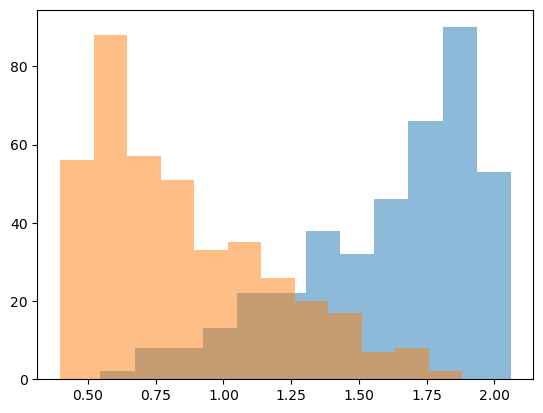

In [141]:
plt.hist(diff_vox_deco[diff_vox_deco.decolabel == 0].ebin, 12, alpha = 0.5)
plt.hist(diff_vox_deco[diff_vox_deco.decolabel == 1].ebin, 12, alpha = 0.5)
plt.show()

In [143]:
nbin_calculator(sns_vox_deco[sns_vox_deco.decolabel == 1].ebin.values)

26

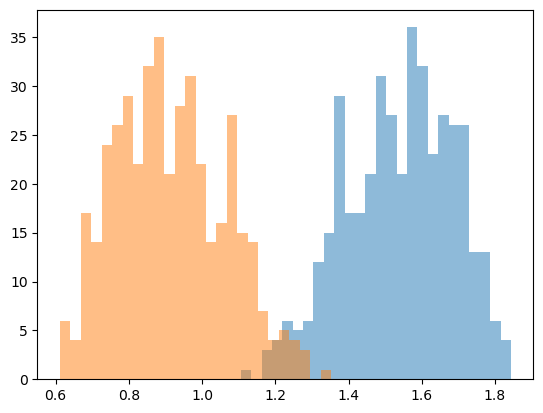

In [144]:
plt.hist(sns_vox_deco[sns_vox_deco.decolabel == 0].ebin, 26, alpha = 0.5)
plt.hist(sns_vox_deco[sns_vox_deco.decolabel == 1].ebin, 26, alpha = 0.5)
plt.show()

In [148]:
nbin_calculator(diff_vox[diff_vox.decolabel == 1].ebin.values)

3499

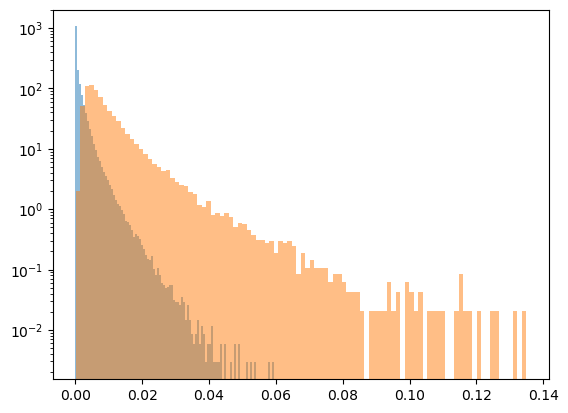

In [151]:
plt.hist(diff_vox[diff_vox.decolabel == 0].ebin, 100, alpha = 0.5, density = True)
plt.hist(diff_vox[diff_vox.decolabel == 1].ebin, 100, alpha = 0.5, density = True)
plt.yscale('log')
plt.show()

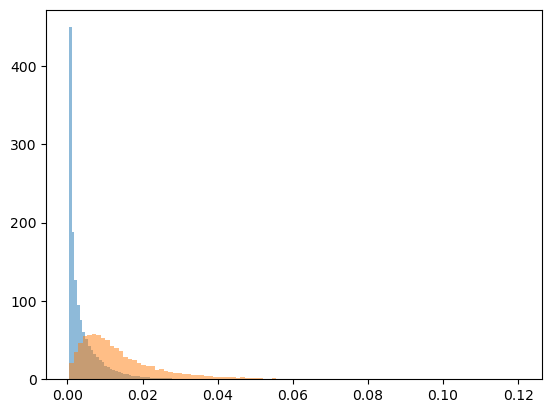

In [168]:
a = plt.hist(sns_vox[sns_vox.decolabel == 0].ebin, 100, alpha = 0.5, density = True)
c = plt.hist(sns_vox[sns_vox.decolabel == 1].ebin, 100, alpha = 0.5, density = True)
# plt.yscale('log')
plt.show()

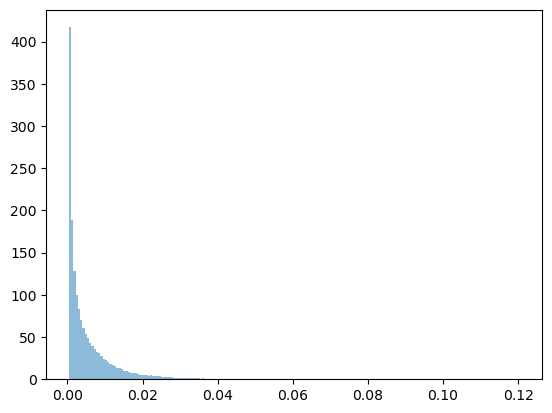

In [156]:
plt.hist(sns_vox.ebin, 200, alpha = 0.5, density = True)
# plt.yscale('log')
plt.show()

In [58]:
import matplotlib as mpl

def plot_3d_hits_func(hits, value='energy', coords = ['x', 'y', 'z'], cmap = mpl.cm.jet, opacity = 1):
    '''
    Function to plot hits

    Args:
        hits: DataFrame or list/tuple/array of lists/tuples/arrays
    Contains the spatial information of the hits and their content. If we don't use a DataFrame, the input
    must have the structure (x, y, z, content), where content is usually the energy or the segclass. Its shape
    will be (4, N).

        value: STR
    Name of the content column in the DataFrame. Will be also the label of the colorbar.

        coords: LIST
    Name of the coords column in the DataFrame.

        cmap: matplotlib.cm
    Used colormap.

        opacity = FLOAT
    Value from 0 to 1 that indicates the opacity of the hits.
    '''

    if type(hits) == type(pd.DataFrame()):
        pass
    else:
        coor = np.array(hits).T
        hits = pd.DataFrame(coor, columns = coords + [value])

    xcoord  = hits[coords[0]].values
    ycoord  = hits[coords[1]].values
    zcoord  = hits[coords[2]].values
    content = hits[value].values

    fig  = plt.figure(figsize=(8, 8), frameon=True)
    gs   = fig.add_gridspec(12, 12)
    ax   = fig.add_subplot(gs[0:12, 0:10], projection = '3d')
    axcb = fig.add_subplot(gs[1:11, 11])
    norm = mpl.colors.Normalize(vmin=min(content), vmax=max(content))

    m    = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    colors = np.asarray(np.vectorize(m.to_rgba)(content))
    colors = np.rollaxis(colors, 0, 2)

    ax.scatter(xcoord, ycoord, zcoord, c=colors * opacity, marker='o')
    cb = mpl.colorbar.ColorbarBase(axcb, cmap=cmap, norm=norm, orientation='vertical')


    ax.set_xlabel('X ')
    ax.set_ylabel('Y ')
    ax.set_zlabel('Z ')
    cb.set_label (value, size = 15)
    cb.ax.tick_params(labelsize=13)
    cb.formatter.set_powerlimits((0, 0))
    return fig, ax

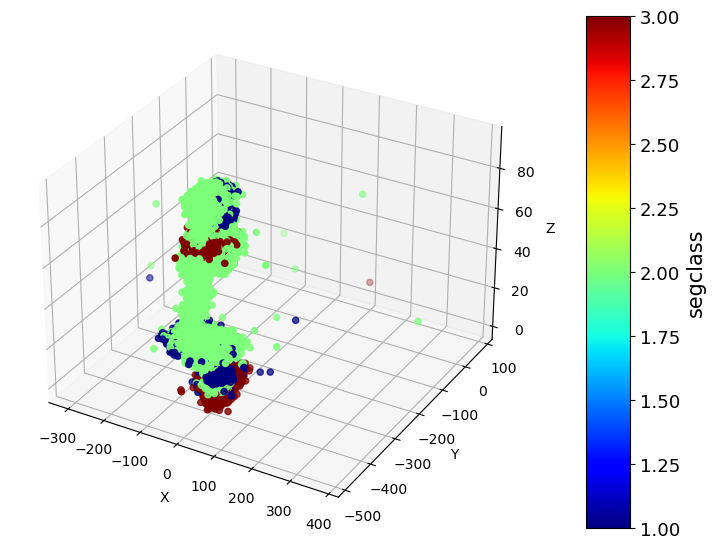

In [66]:
fig, ax = plot_3d_hits_func(event['sns_df'], 'segclass', ['x_sipm', 'y_sipm', 'z_slice'], cmap=mpl.cm.jet)

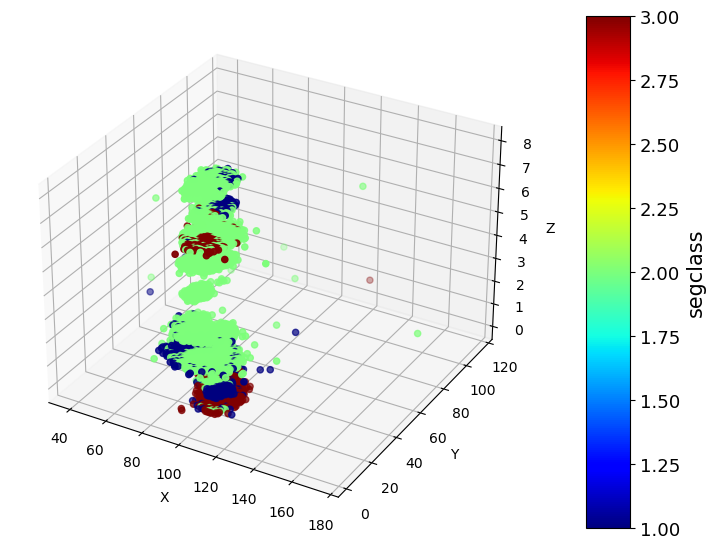

In [62]:
fig, ax = plot_3d_hits_func(event['sns_vox_df'], 'segclass', ['xbin', 'ybin', 'zbin'], cmap=mpl.cm.jet)

In [189]:
from matplotlib.animation import FuncAnimation

# Define the rotation function
def rotate(angle):
    ax.view_init(elev=30, azim=angle)

# Create the animation
anim = FuncAnimation(fig, lambda frame: rotate(frame), frames=np.arange(0, 360, 5), interval=50)

# Display or save the animation
anim.save('/Users/mperez/detsim_vox/3d_rotation.gif', writer='imagemagick')  # Save as GIF
# plt.show()  # Uncomment to just display the animation


MovieWriter imagemagick unavailable; using Pillow instead.
Animation.save using <class 'matplotlib.animation.PillowWriter'>
